In [3]:
import numpy as np
from sim_library.plotting import plot_bloch, plot_bloch_multi
from sim_library.sequences import UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFEdown_seq, gen_MDFEup_seq
from sim_library.simulation import simulate_pulses_single_atom_analyt
from sim_library.constants import hbar, k_eff, dR, pi

(<qutip.bloch.Bloch at 0x1aeba45ef30>, <Figure size 700x700 with 1 Axes>)

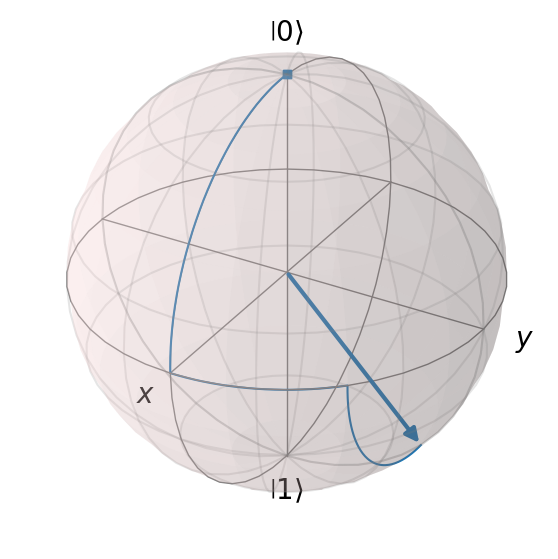

In [ ]:
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 100

free_time = pi/(4*dR)
detuning = 0*dR

ramsey_gate = PulseSequence()
pulse1 = UpPulse(laser_det=np.full(time_steps,detuning), phase=np.full(time_steps,pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
pulse2 = UpPulse(laser_det=np.full(time_steps,detuning), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
pulse3 = DownPulse(laser_det=np.full(time_steps,detuning), phase=np.full(time_steps,0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
freevolve1 = FreeEvolution(laser_det=np.full(time_steps,detuning), duration=free_time/8 - (1/rabi_freq) - (pi/(2*rabi_freq)))
freevolve2 = FreeEvolution(laser_det=np.full(time_steps,detuning), duration=free_time/4 - (pi/rabi_freq))
ramsey_gate.add_pulses([pulse1, freevolve1, pulse3, freevolve2, pulse3, freevolve1, pulse2])

ramsey_interf = PulseSequence()
freevolve3 = FreeEvolution(laser_det=np.full(time_steps,detuning), duration=free_time - (2/rabi_freq))
ramsey_interf.add_pulses([pulse1, freevolve3, pulse2])

p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=ramsey_interf, basis=basis, initial_state=initial_state)

b, fig = plot_bloch_multi(wave_func=wave_func[np.newaxis,:,8:10])
b.




  
